In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

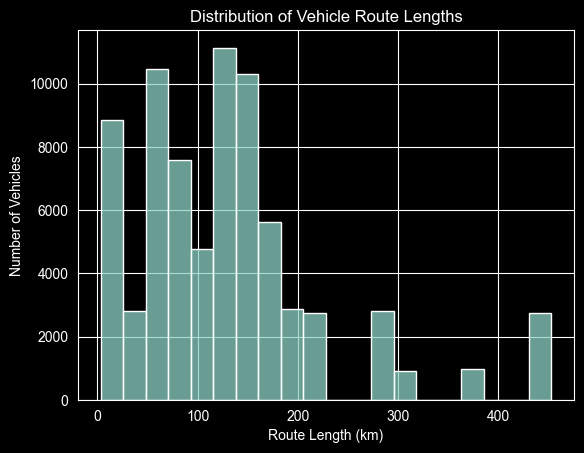

In [11]:
df_routes = pd.read_csv('scenario0_routes.csv')
sns.histplot(df_routes['route_length_km'], bins=20)
plt.xlabel("Route Length (km)")
plt.ylabel("Number of Vehicles")
plt.title("Distribution of Vehicle Route Lengths")
plt.show()

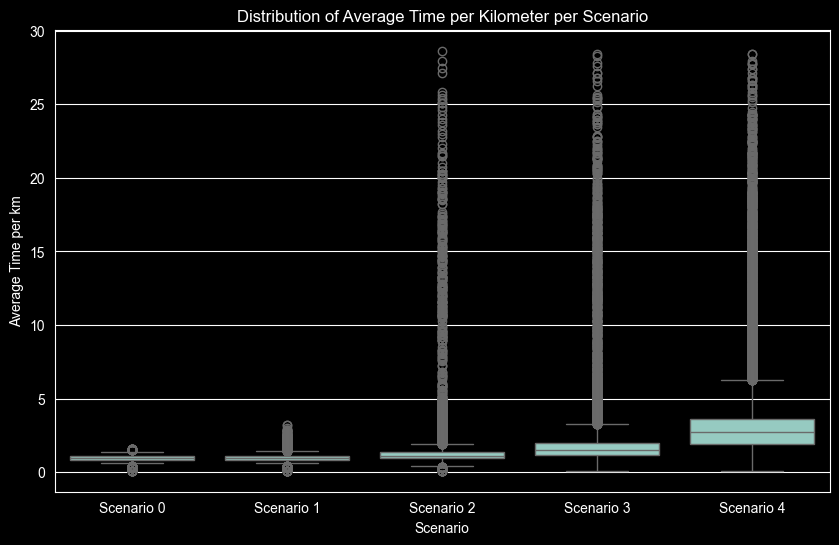

In [14]:
# List of your CSV files for each scenario
files = [
    "scenario0_routes.csv",
    "scenario1_routes.csv",
    "scenario2_routes.csv",
    "scenario3_routes.csv",
    "scenario4_routes.csv"
]

# Combine all scenarios into one DataFrame
dfs = []
for i, f in enumerate(files):
    df = pd.read_csv(f)
    df['scenario'] = f"Scenario {i}"
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

# Calculate time per kilometer
df_all['time_per_km'] = df_all['driving_time_min'] / df_all['route_length_km']  # adjust column names if needed

# Plot boxplot with average overlay
plt.figure(figsize=(10, 6))
sns.boxplot(x='scenario', y='time_per_km', data=df_all)
#sns.pointplot(x='scenario', y='time_per_km', data=df_all, color='red', estimator='mean', ci=None)
plt.xlabel("Scenario")
plt.ylabel("Average Time per km")
plt.title("Distribution of Average Time per Kilometer per Scenario")
plt.show()

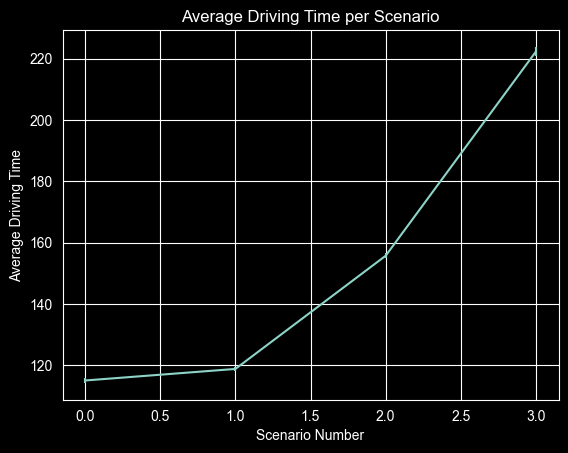

In [18]:
files = {}
for i in range(0, 4):
    files[i] = pd.read_csv(f'scenario{i}_A3.csv')

scenario_numbers = []
means = []
lower_errors = []
upper_errors = []

for key in files:
    df = files[key]

    number = df["scenario"].iloc[0]
    mean = df["scenario_mean"].iloc[0]
    ci_lower = df["ci_95_lower"].iloc[0]
    ci_upper = df["ci_95_upper"].iloc[0]

    scenario_numbers.append(number)
    means.append(mean)
    lower_errors.append(mean - ci_lower)
    upper_errors.append(ci_upper - mean)

plt.figure()

plt.errorbar(
    scenario_numbers,
    means,
    yerr=[lower_errors, upper_errors],
)

plt.xlabel("Scenario Number")
plt.ylabel("Average Driving Time")
plt.title("Average Driving Time per Scenario")
plt.show()